# **📊 Customer Churn Analysis**

Hey! In this project, I'm analyzing a telecom company's customer data to understand **why customers are leaving (churning)**.

The dataset has **7,043 customers** with info like their contract type, payment method, internet service, monthly charges, and whether they stayed or left.

My goal is simple - **figure out who's churning and why**, so the business can actually do something about it.

# **🔍 First Look at the Data** 

Let's load the data and see what we're working with. I want to check the shape, column types, and if there are any missing values.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

churn_data = pd.read_csv("/kaggle/input/datasets/abedmiah/database/churn_data.csv.csv")

churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 🧹 Cleaning Things Up

Before jumping into analysis, I need to fix a few things:

- **TotalCharges** is stored as text, so I'll convert it to numbers.
- **Churn** needs to be 0/1 instead of "Yes"/"No" — much easier to work with.
- **SeniorCitizen** is already 0/1, so I'll leave it as is.

In [2]:
print(churn_data.shape)
print(churn_data.info())
print(churn_data.describe())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [3]:
print(churn_data["Churn"].unique())
print(churn_data["SeniorCitizen"].unique())

['No' 'Yes']
[0 1]


In [4]:
print(churn_data.isnull().sum())
print("Duplicate rows:", churn_data.duplicated().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Duplicate rows: 0


In [5]:

churn_data["TotalCharges"] = pd.to_numeric(
    churn_data["TotalCharges"], errors="coerce"
)

churn_data["Churn"] = churn_data["Churn"].map({"Yes": 1, "No": 0})

churn_data[["TotalCharges", "SeniorCitizen", "Churn"]].head()

,TotalCharges,SeniorCitizen,Churn
0,29.85,0,0
1,1889.50,0,0
2,108.15,0,1
3,1840.75,0,0
4,151.65,0,1


In [6]:
churn_data.groupby("SeniorCitizen")["Churn"].mean().mul(100).round(2)

SeniorCitizen
0    23.61
1    41.68
Name: Churn, dtype: float64

In [7]:
payment_churn= churn_data.groupby("PaymentMethod")["Churn"].mean().mul(100).round(2)

print(payment_churn)

PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64


In [8]:
internet_churn= churn_data.groupby("InternetService")["Churn"].mean().mul(100).round(2)

print(internet_churn)

InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64


In [9]:
churn_data.groupby("Churn")["tenure"].mean().head(2)

Churn
0    37.569965
1    17.979133
Name: tenure, dtype: float64

In [10]:
churn_data.groupby("Churn")["MonthlyCharges"].mean().head(2)

Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64

<Axes: title={'center': 'Customer Churn Distribution'}, xlabel='Churn'>

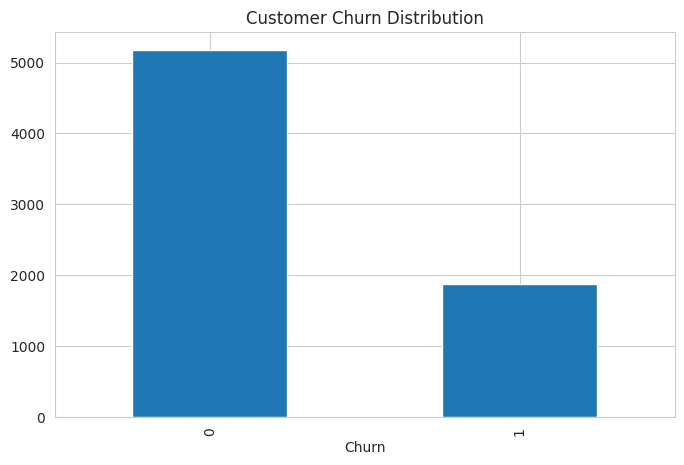

In [11]:
churn_data["Churn"].value_counts().plot(
    kind="bar",
    title="Customer Churn Distribution"
)

<Axes: title={'center': 'Churn rate by contract'}, xlabel='Contract'>

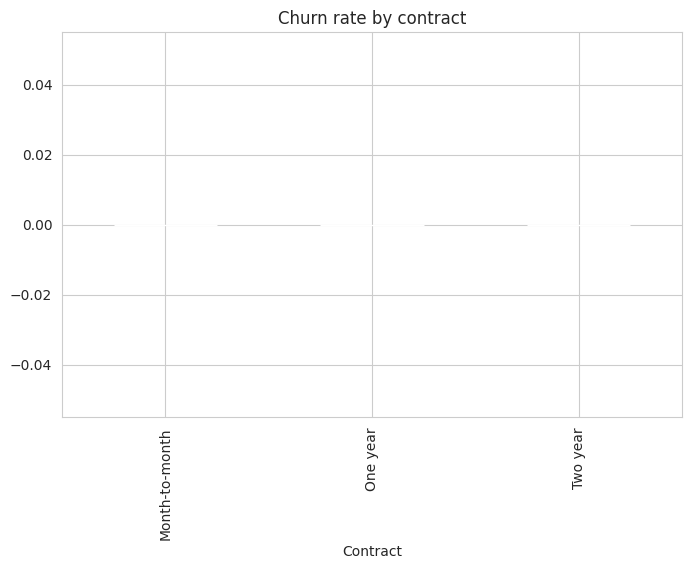

In [12]:
contract_churn = (
    churn_data.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean())
)

contract_churn.plot(
    kind="bar",
    title="Churn rate by contract"
)

<Axes: title={'center': 'Churn rate by contract'}, xlabel='Contract'>

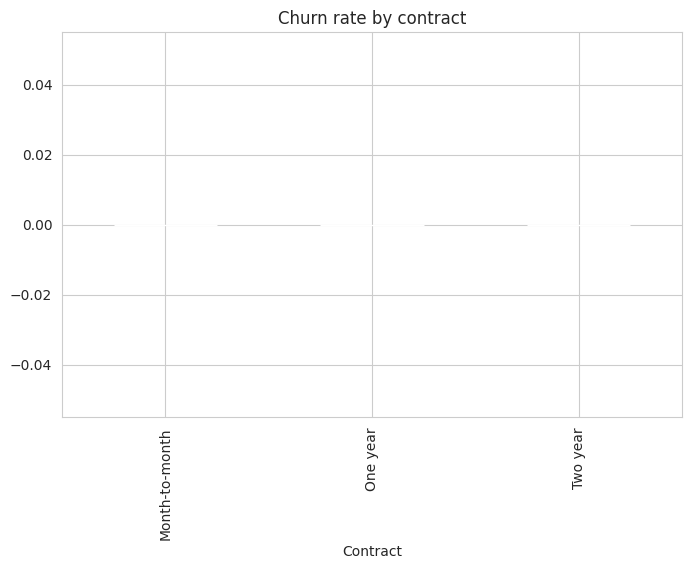

In [13]:
contract_churn.plot(
    kind="bar",
    title="Churn rate by contract"
)

<Axes: title={'center': 'churn rate by payment method'}, xlabel='PaymentMethod'>

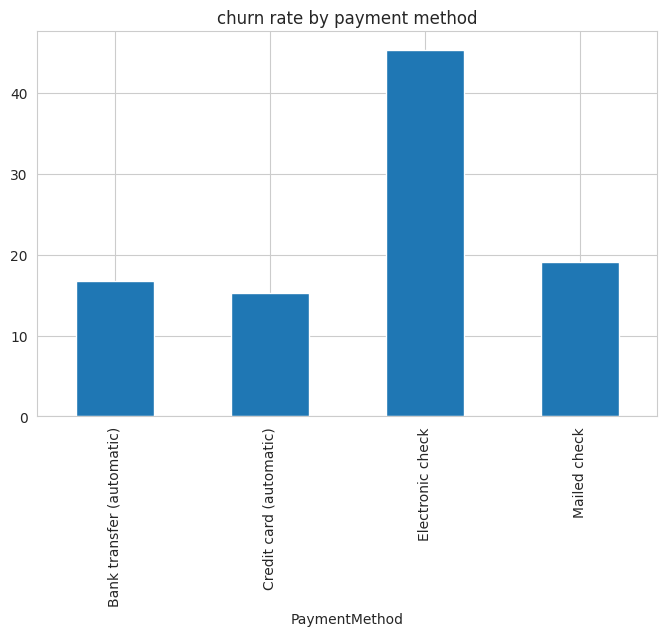

In [14]:
payment_churn.plot(
    kind="bar",
    title="churn rate by payment method"
)

<Axes: title={'center': 'churn rate by internet service'}, xlabel='InternetService'>

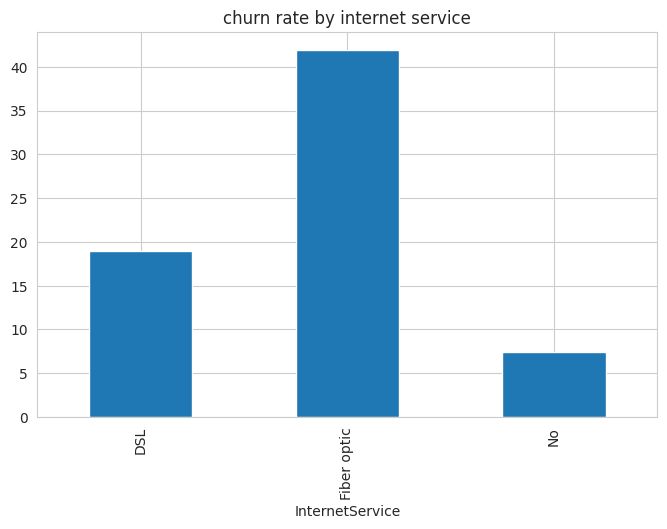

In [15]:
internet_churn.plot(
    kind="bar",
    title="churn rate by internet service"
)

In [16]:
high_risk = churn_data[
    (churn_data["Contract"] == "Month-to-month") &
    (churn_data["tenure"] < 12) &
    (churn_data["MonthlyCharges"] > churn_data["MonthlyCharges"].median())
]

print(high_risk.shape)

(770, 21)


In [17]:
high_value = churn_data[
    churn_data["MonthlyCharges"] > churn_data["MonthlyCharges"].median()
]

print(high_value.shape)

(3515, 21)


In [18]:
total_customers = churn_data.shape[0]

print("total customers:", total_customers)

total customers: 7043


In [19]:
churned_customers = churn_data["Churn"].sum()

print("churned customers:", churned_customers)

churned customers: 1869


In [20]:
avg_monthly_charge = churn_data["MonthlyCharges"].mean()

print("average monthly charge:", round(avg_monthly_charge, 2))

average monthly charge: 64.76


## 📈 How Bad Is the Churn Problem?

First thing — let's see the overall churn rate. This gives us a baseline to compare everything else against.

Overall Churn Rate: 26.54%


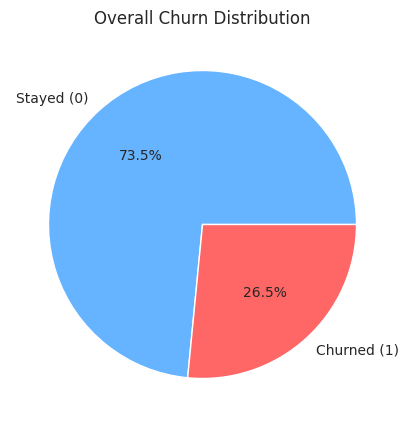

In [21]:
overall_churn = churn_data["Churn"].mean() * 100
print(f"Overall Churn Rate: {overall_churn:.2f}%")

# Chart
churn_data["Churn"].value_counts().plot(
    kind="pie", labels=["Stayed (0)", "Churned (1)"],
    autopct="%1.1f%%", colors=["#66b3ff", "#ff6666"]
)
plt.title("Overall Churn Distribution")
plt.ylabel("")
plt.show()

## 📋 Does Contract Type Matter?

Quick question — do customers on long-term contracts stay longer? Let's find out.

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


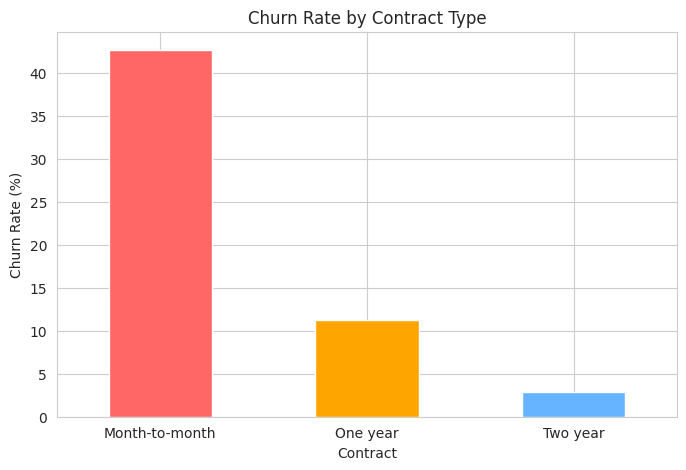

In [22]:
contract_churn = churn_data.groupby("Contract")["Churn"].mean().sort_values(ascending=False) * 100
print(contract_churn)

# Chart
contract_churn.plot(kind="bar", color=["#ff6666", "#ffa500", "#66b3ff"])
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## 💳 Which Payment Method Has the Most Churn?

Some payment methods are painful to use. Maybe that's pushing customers away. Let's check.

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64


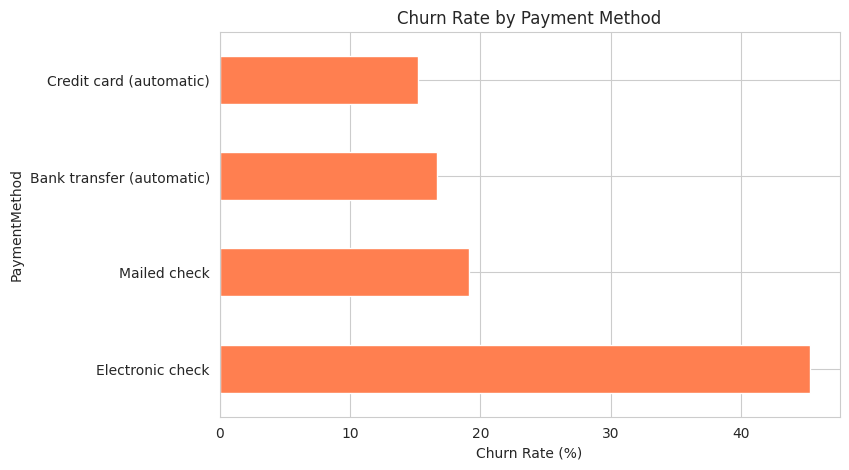

In [23]:
payment_churn = churn_data.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False) * 100
print(payment_churn)

payment_churn.plot(kind="barh", color="coral")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.show()

## 🌐 Internet Service — Fiber vs DSL

Fiber optic is supposed to be the premium option. But is it actually keeping customers happy? Let's see.

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


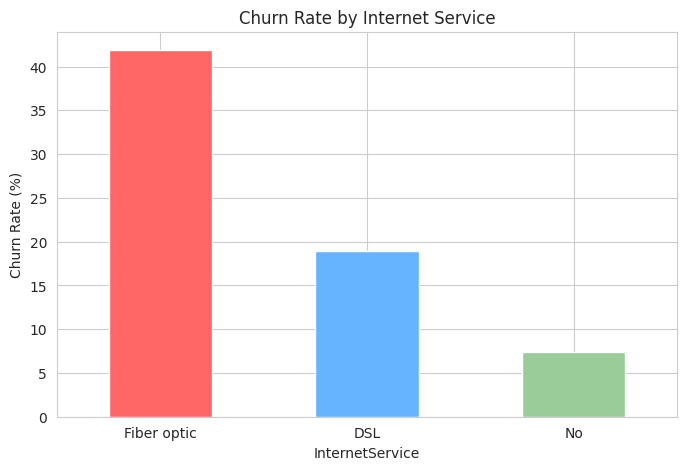

In [24]:
internet_churn = churn_data.groupby("InternetService")["Churn"].mean().sort_values(ascending=False) * 100
print(internet_churn)


internet_churn.plot(kind="bar", color=["#ff6666", "#66b3ff", "#99cc99"])
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## ⏳ Do New Customers Leave Faster?

This is a big one. My guess is new customers churn more — let's see if the data agrees.

TenureGroup
0-1 yr    47.678161
1-2 yr    28.710938
2-4 yr    20.388959
4-6 yr     9.513176
Name: Churn, dtype: float64


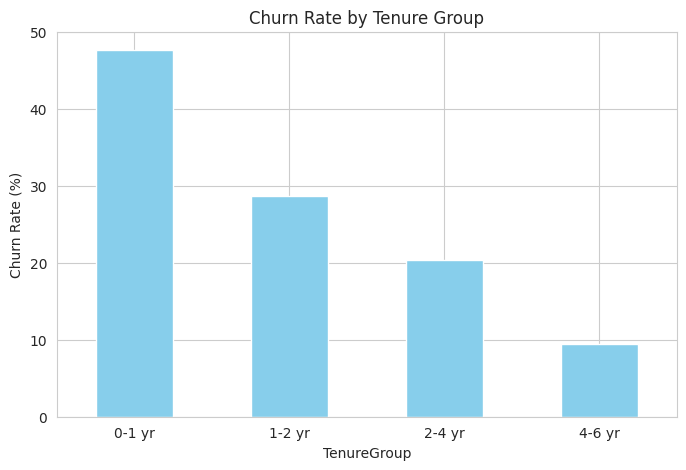

In [25]:
churn_data["TenureGroup"] = pd.cut(
    churn_data["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1 yr", "1-2 yr", "2-4 yr", "4-6 yr"]
)

tenure_churn = churn_data.groupby("TenureGroup", observed=True)["Churn"].mean() * 100
print(tenure_churn)


tenure_churn.plot(kind="bar", color="skyblue")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [26]:
print(churn_data.groupby("TenureGroup", observed=True)["MonthlyCharges"].mean())

TenureGroup
0-1 yr    56.172023
1-2 yr    61.357275
2-4 yr    65.930552
4-6 yr    73.945377
Name: MonthlyCharges, dtype: float64


## 💰 Are Expensive Plans Driving People Away?

If customers are paying more, they expect more. Let's see if higher monthly charges lead to more churn.

ChargeGroup
Low          11.237230
Medium       24.575311
High         37.507114
Very High    32.878271
Name: Churn, dtype: float64


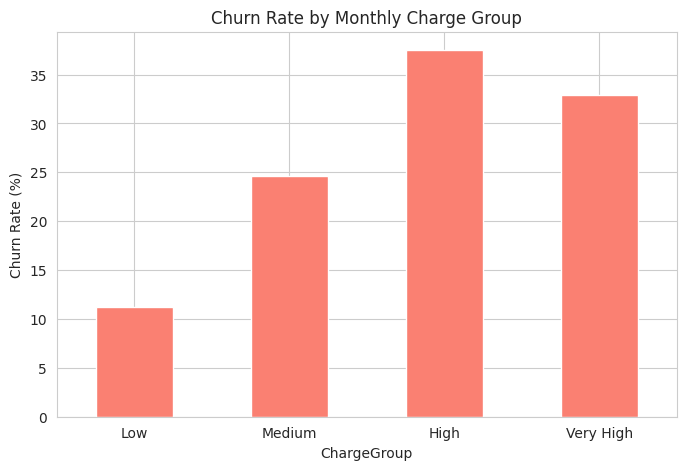

In [27]:
# Monthly charge binning
churn_data["ChargeGroup"] = pd.qcut(
    churn_data["MonthlyCharges"], q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

charge_churn = churn_data.groupby("ChargeGroup", observed=True)["Churn"].mean() * 100
print(charge_churn)

# Chart
charge_churn.plot(kind="bar", color="salmon")
plt.title("Churn Rate by Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

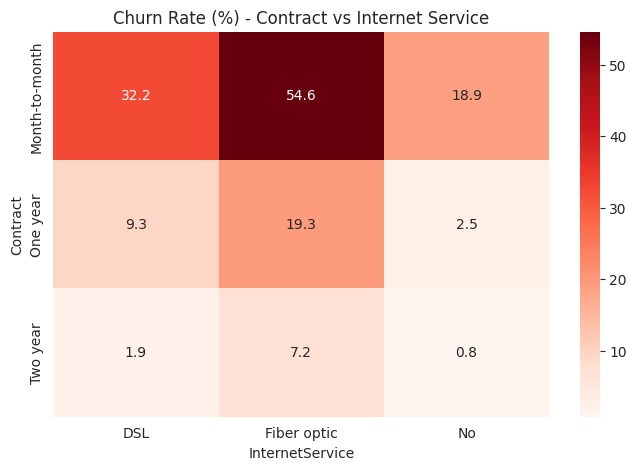

In [28]:
pivot = churn_data.pivot_table(
    values="Churn", index="Contract",
    columns="InternetService", aggfunc="mean"
) * 100

sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("Churn Rate (%) - Contract vs Internet Service")
plt.show()

## 🎯 Final Dashboard — The Big Picture

Alright, here's everything in one place. This dashboard summarizes the entire analysis at a glance.

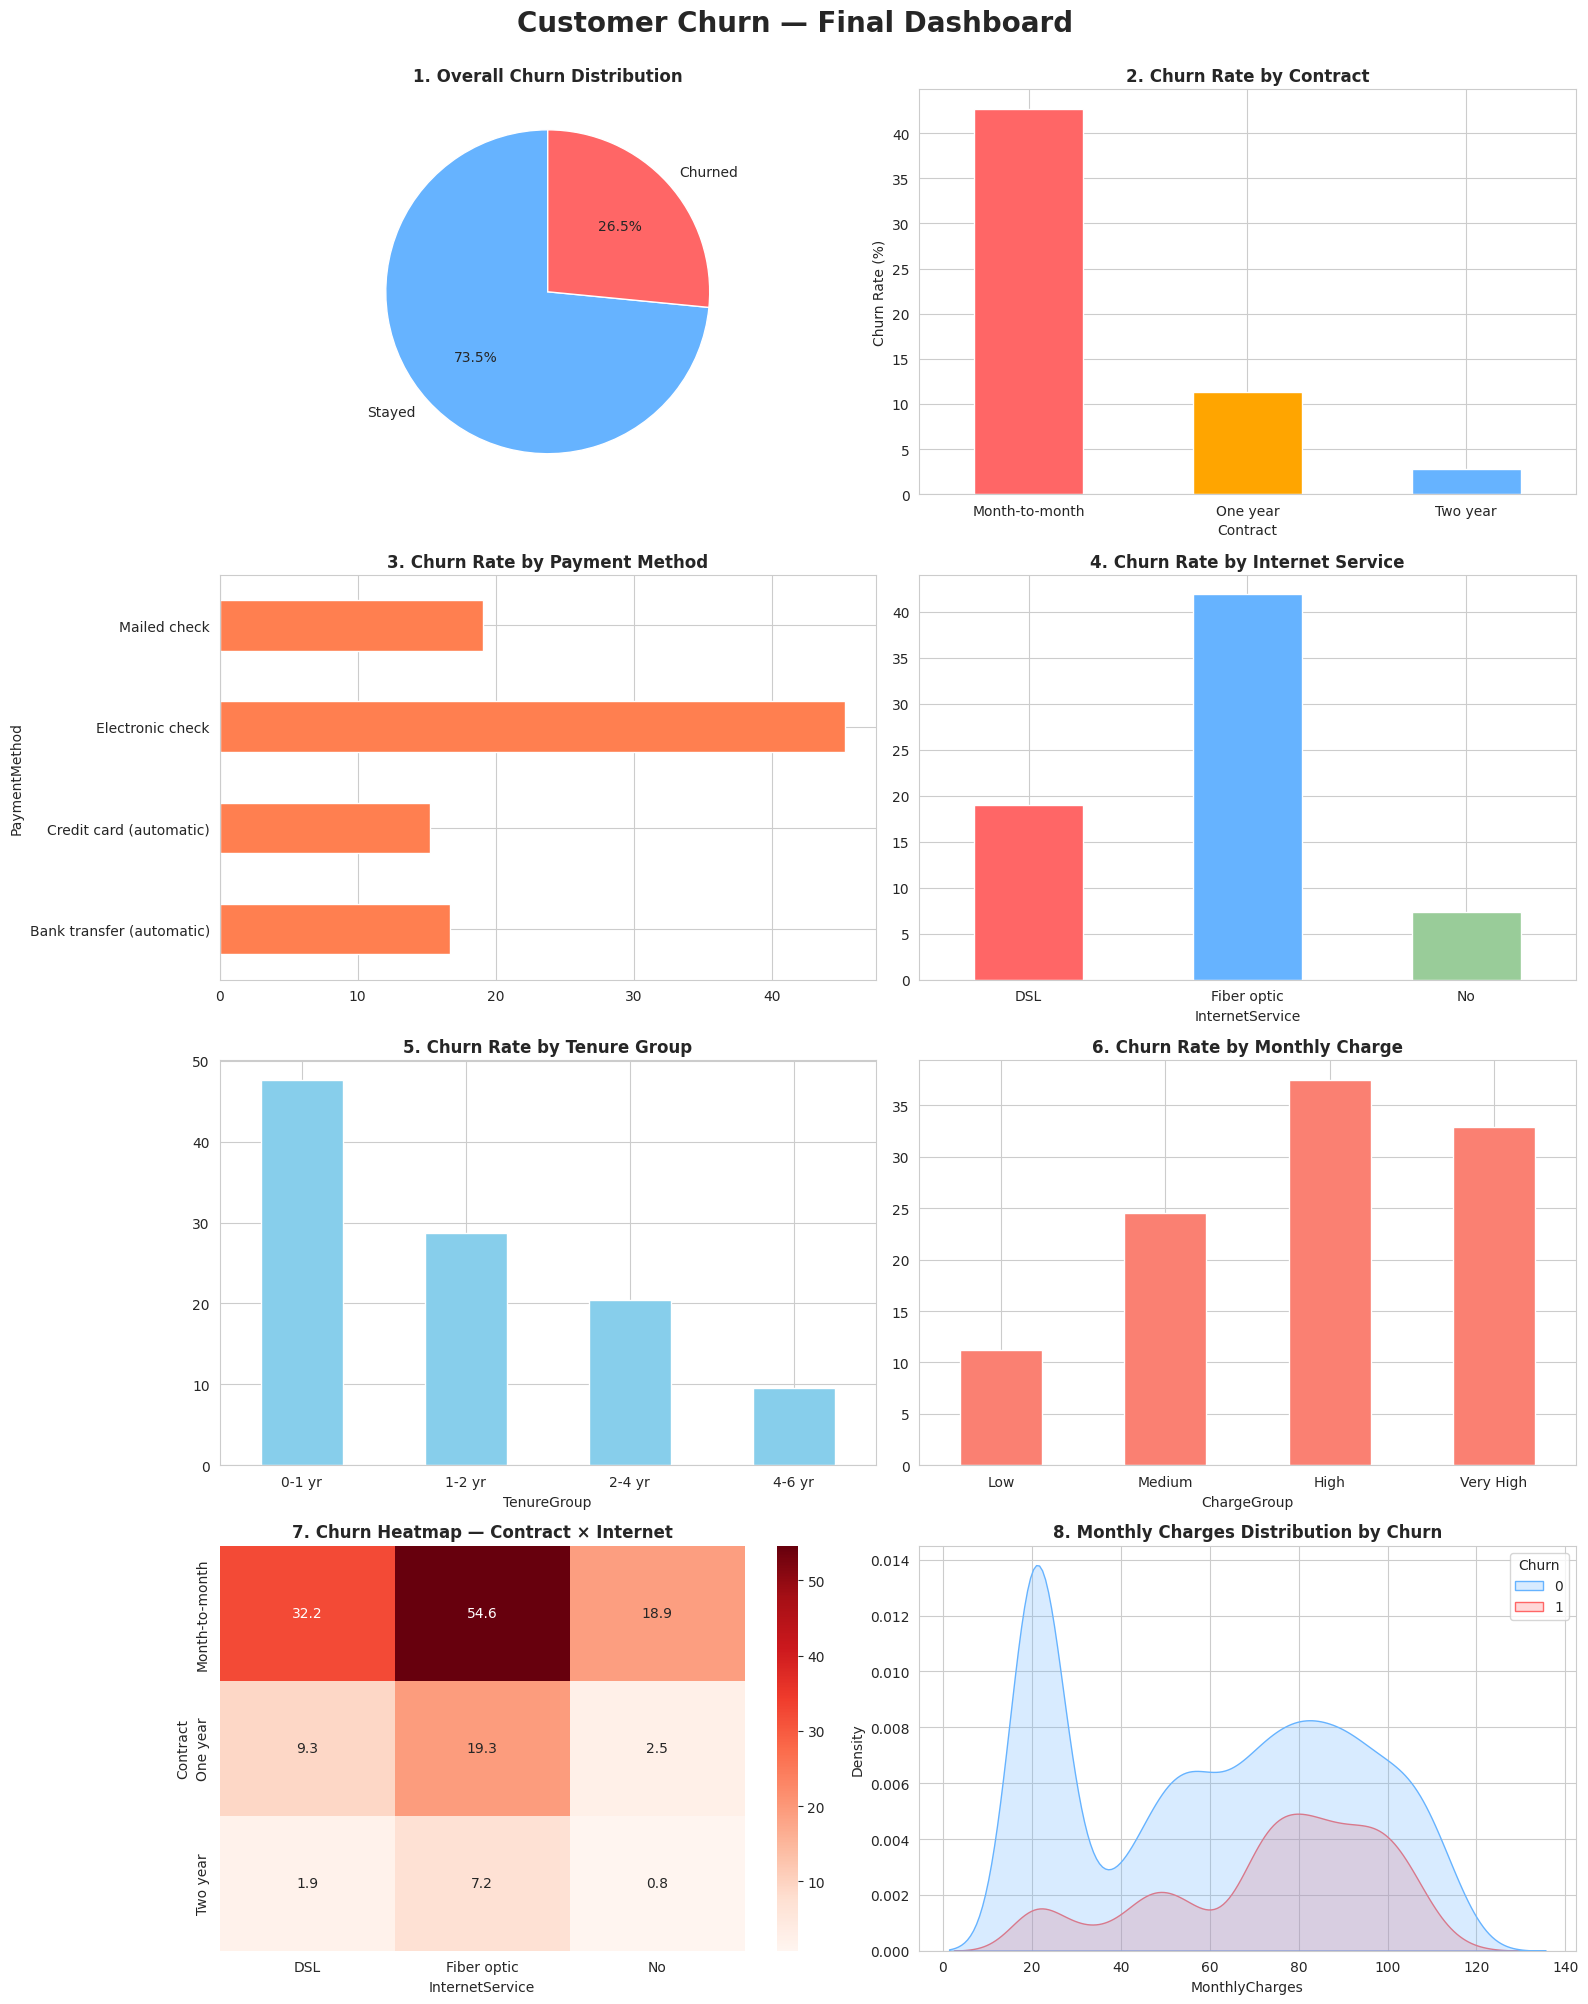

In [29]:
# ============================================
# 🎯 FINAL DASHBOARD — Customer Churn Summary
# ============================================

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle("Customer Churn — Final Dashboard", 
             fontsize=20, fontweight="bold", y=1.00)

# 1. Churn Distribution (Pie)
churn_data["Churn"].value_counts().plot(
    kind="pie", labels=["Stayed", "Churned"],
    autopct="%1.1f%%", colors=["#66b3ff", "#ff6666"],
    ax=axes[0, 0], startangle=90
)
axes[0, 0].set_title("1. Overall Churn Distribution", fontweight="bold")
axes[0, 0].set_ylabel("")

# 2. Churn by Contract
(churn_data.groupby("Contract")["Churn"].mean() * 100).plot(
    kind="bar", color=["#ff6666", "#ffa500", "#66b3ff"], ax=axes[0, 1]
)
axes[0, 1].set_title("2. Churn Rate by Contract", fontweight="bold")
axes[0, 1].set_ylabel("Churn Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=0)

# 3. Churn by Payment Method
(churn_data.groupby("PaymentMethod")["Churn"].mean() * 100).plot(
    kind="barh", color="coral", ax=axes[1, 0]
)
axes[1, 0].set_title("3. Churn Rate by Payment Method", fontweight="bold")

# 4. Churn by Internet Service
(churn_data.groupby("InternetService")["Churn"].mean() * 100).plot(
    kind="bar", color=["#ff6666", "#66b3ff", "#99cc99"], ax=axes[1, 1]
)
axes[1, 1].set_title("4. Churn Rate by Internet Service", fontweight="bold")
axes[1, 1].tick_params(axis="x", rotation=0)

# 5. Tenure vs Churn
(churn_data.groupby("TenureGroup", observed=True)["Churn"].mean() * 100).plot(
    kind="bar", color="skyblue", ax=axes[2, 0]
)
axes[2, 0].set_title("5. Churn Rate by Tenure Group", fontweight="bold")
axes[2, 0].tick_params(axis="x", rotation=0)

# 6. Monthly Charges vs Churn
(churn_data.groupby("ChargeGroup", observed=True)["Churn"].mean() * 100).plot(
    kind="bar", color="salmon", ax=axes[2, 1]
)
axes[2, 1].set_title("6. Churn Rate by Monthly Charge", fontweight="bold")
axes[2, 1].tick_params(axis="x", rotation=0)

# 7. Heatmap
pivot = churn_data.pivot_table(
    values="Churn", index="Contract",
    columns="InternetService", aggfunc="mean"
) * 100
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds", ax=axes[3, 0])
axes[3, 0].set_title("7. Churn Heatmap — Contract × Internet", fontweight="bold")

# 8. Monthly Charges Distribution
sns.kdeplot(
    data=churn_data, x="MonthlyCharges", hue="Churn",
    fill=True, palette=["#66b3ff", "#ff6666"], ax=axes[3, 1]
)
axes[3, 1].set_title("8. Monthly Charges Distribution by Churn", fontweight="bold")

plt.tight_layout()
plt.show()

## 💡 What I Learned

Here's what the data actually told me:

**1. Overall churn rate is around 26%** — that's a lot. Roughly 1 in 4 customers is leaving.

**2. Contract type matters the most.** Month-to-month customers churn way more than those on 1 or 2-year contracts. Long-term commitment = loyalty.

**3. Electronic check users churn the most.** Auto-payment customers stick around longer — probably because manual payments are a hassle.

**4. Fiber optic customers churn more than DSL users.** This is surprising since fiber is the premium product. Might be a price or service quality issue.

**5. New customers (under 1 year) are the most likely to leave.** If they survive the first year, they usually stay. So the first 12 months are critical.

**6. Higher monthly charges = higher churn.** Makes sense — people paying more expect more value.

**7. The riskiest group?** Month-to-month + fiber optic + new customer + high monthly charge. That's the segment the company should target with retention offers.

---

**Bottom line:** The company should focus on converting month-to-month customers to long-term contracts, pushing auto-payment, and improving the fiber optic experience. Those three moves alone could cut churn significantly.